In [3]:
from zfish._io import import16chFlt
from zfish.local_path import *
import os

import numpy as np
import matplotlib.pyplot as plt
from zfish.utils import *

code_id = "5009 - Dat Line Optogenetic"
loc = os.path.join(figpath, code_id)
os.makedirs(loc, exist_ok=True)

landmark_pos = [
    (0, 1/18), # Starting Point box
    (2/18, 3/18), # Leaves
    (6/18, 7/18), # Stars
    (8/18, 9/18), # triangles
    (10/18, 11/18), # Polygons
    (14/18, 15/18), # Teeth of Predators
    (16/18, 17/18) # Gravel
]

# Go-Stop-Go

In [48]:
res = import16chFlt(r"D:\EnData\dat\10211\S2\res.16chFlt")

idx = np.where((res['behav_pos_y'] < 50)&(res['behav_time'] > 5))[0]
for k in res.keys():
    res[k] = res[k][idx]

In [49]:
dx = np.diff(res['behav_pos_y'])
dx[dx < -48] += 50
dx[dx > 48] -= 50
dt = np.diff(res['behav_time'])

v = dx/dt#np.convolve(dx, np.ones(100), mode='same') / np.convolve(dt, np.ones(200), mode='same')
v = np.append(v, 0)


Text(0.5, 0, 'Time (s)')

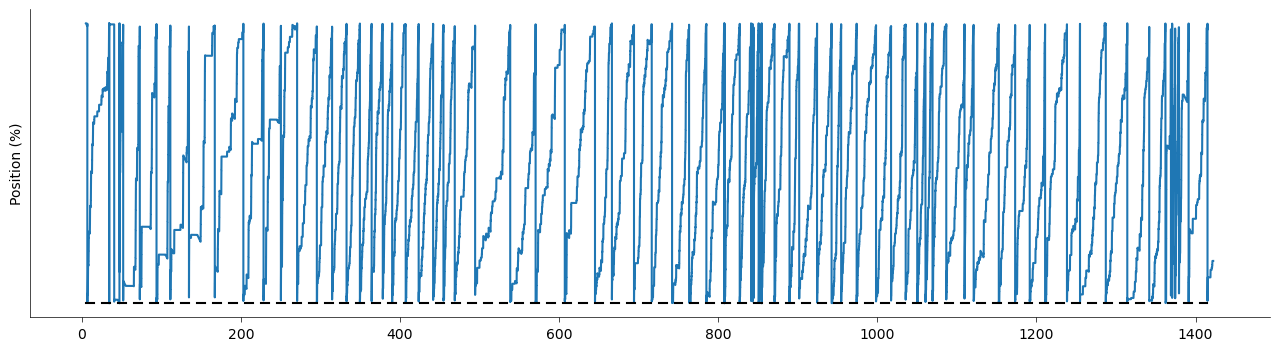

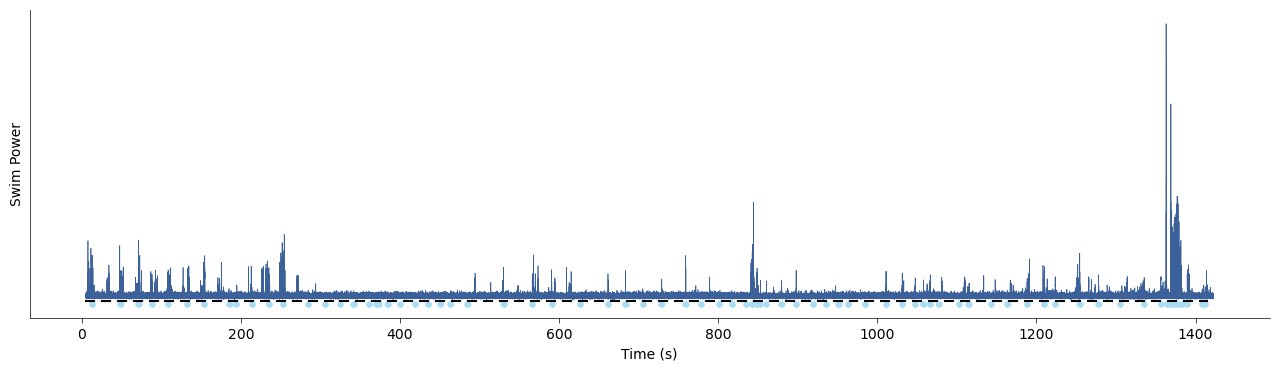

In [60]:
_range = np.arange(8499000)
fig = plt.figure(figsize=(16, 4))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=False)
ax.plot(res['behav_time'][_range], res['behav_pos_y'][_range]*2)
for i in np.arange(5, res['behav_time'][_range][-1], 20):
    ax.plot([i, i+10], [0, 0], 'k')
ax.set_ylabel("Position (%)")
    
    
fig = plt.figure(figsize=(16, 4))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=False)
ax.plot(res['behav_time'][_range], (res['fltCh1'][_range]), color=ChannelColors[1], linewidth=0.5)
for i in np.arange(5, res['behav_time'][_range][-1], 20):
    ax.plot([i, i+10], [0, 0], 'k')
    
dled = np.where(np.diff(res['opto_states']) == 1)[0]
ax.scatter(res['behav_time'][dled], np.repeat(-1e-5, len(dled)), color='#a9dcf5', s=10, edgecolor=None)
ax.set_ylabel("Swim Power")
ax.set_xlabel("Time (s)")

# New Task

In [2]:
path = r"D:\EnData\dat\Negative - GCaMP8m\10184\S2\res.16chFlt"


if os.path.exists(os.path.join(figdata, f" {code_id}.pkl")) == False:
    data = {
        "Fish ID": [],
        "LED Power": [],
        "Pos": [],
        "Time": [],
        "Label": [],
        "Group": []
    }
    
    for fid, gp, data_file_dir in tqdm(zip(
        [10186, 10187, 10188, 10189, 10190, 10191, 10192, 10195, 10197, 10198, 10202, 10203],
        ["Negative", "Positive", "Positive", "Positive", "Positive", "Negative", "Negative", "Negative", "Negative", "Negative", "Positive", "Positive"],
        [r"D:\EnData\dat\Negative - GCaMP8m\10184\S2\res.16chFlt",
         r"D:\EnData\dat\10186\S2\res.16chFlt",
         r"D:\EnData\dat\10187\S2\res.16chFlt",
         r"D:\EnData\dat\10188\S2\res.16chFlt",
         r"D:\EnData\dat\10189\S2\res.16chFlt",
         r"D:\EnData\dat\Negative - datCoChr-\10190\S2\res.16chFlt",
         r"D:\EnData\dat\Negative - datCoChr-\10191\S2\res.16chFlt",
         r"D:\EnData\dat\Negative - datCoChr-\10192\S2\res.16chFlt",
         r"D:\EnData\dat\Negative - datCoChr-\10195\S2\res.16chFlt",
         r"D:\EnData\dat\Negative - datCoChr-\10197\S2\res.16chFlt",
         r"D:\EnData\dat\Negative - datCoChr-\10198\S2\res.16chFlt",
         r"D:\EnData\dat\10202\S2\res.16chFlt",
         r"D:\EnData\dat\10203\S2\res.16chFlt"]
    )):
        res = import16chFlt(data_file_dir)
        idx = np.where(
            (res['behav_time'] > 5) &
            (res['behav_pos_y'] >= 0) &
            (res['behav_pos_y'] < 55) &
            (res['n_trials'] < 70)
        )[0]
        for k in res.keys():
            res[k] = res[k][idx]

        res['behav_pos_y'] = res['behav_pos_y']*2

        indices = [
            (np.where((res['n_trials'] >= i*5) & (res['n_trials'] < (i+1)*5))[0], [0, 0.2, 0.5, 0.8, 1.5, 3.0, 5.0][i//2], ["stim", "test"][i%2]) for i in range(14)
        ]        
        
        print(np.max(res['behav_pos_y']), np.min(res['behav_pos_y']))
        
        x = np.linspace(0, 100, 46)
        x = (x[:-1] + x[1:])/2
        for it in indices:
            idx, led_power, label = it
            if idx.shape[0] < 6000:
                continue
            tt = np.histogram(res['behav_pos_y'][idx], bins = 45, range=(0,100), density=True)[0]
            data["Fish ID"].append(np.repeat(fid, len(tt)))
            data["LED Power"].append(np.repeat(led_power, len(tt)))
            data["Pos"].append(x)
            data["Time"].append(tt)
            data["Label"].append(np.repeat(label, len(tt)))
            data["Group"].append(np.repeat(gp, len(tt)))
        
    for key in data:
        data[key] = np.concatenate(data[key])
        
    with open(os.path.join(figdata, f"{code_id}.pkl"), "wb") as f:
        pickle.dump(data, f)
    
    try:
        D = pd.DataFrame(data)
        D.to_excel(os.path.join(figdata, f"{code_id}.xlsx"), index=False)
    except:
        pass
    print(len(D))
else:
    with open(os.path.join(figdata, f"{code_id}.pkl"), "rb") as f:
        data = pickle.load(f)

1it [00:01,  1.78s/it]

0.4499999999999999 0.009999999999999998
0.44999999999999996 0.009999999999999998
0.4499999999999999 0.009999999999999998
0.44999999999999984 0.009999999999999997
0.4499999999999999 0.009999999999999998
0.44999999999999996 0.009999999999999998
0.45 0.01
0.44999999999999996 0.009999999999999998
0.4500000000000002 0.010000000000000004
0.44999999999999996 0.009999999999999998
0.45000000000000007 0.010000000000000002
0.44999999999999996 0.009999999999999998
0.44999999999999996 0.009999999999999998
0.45000000000000007 0.010000000000000002


2it [00:06,  3.52s/it]

0.45000000000000007 0.010000000000000002


3it [00:17,  6.89s/it]

...

11it [01:09,  8.25s/it]

0.44999999999999996 0.009999999999999998
0.45 0.01
0.45000000000000007 0.010000000000000002
0.45 0.01


12it [01:12,  6.07s/it]

0.4500000000000001 0.010000000000000002
0.4499999999999998 0.009999999999999995
0.45 0.01
0.45 0.01
0.4499999999999999 0.009999999999999998
0.44999999999999996 0.009999999999999998
0.45000000000000007 0.010000000000000002
0.4499999999999999 0.009999999999999998
0.4500000000000001 0.010000000000000002
0.45000000000000007 0.010000000000000002
0.45 0.01
0.45 0.01
0.45000000000000007 0.010000000000000002
0.44999999999999984 0.009999999999999997


6300


# Positive Fish

495
450
360
360
360
360
360


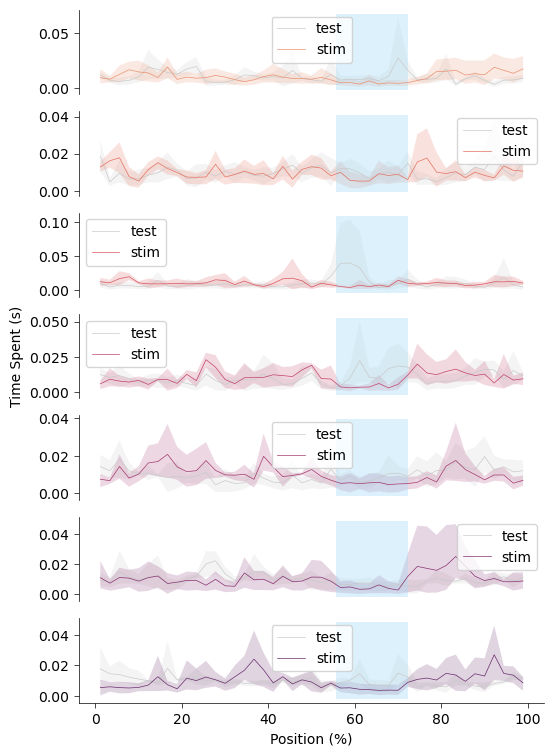

In [19]:
fig, axes = plt.subplots(nrows=7, ncols=1, figsize=(6, 9))
colors = sns.color_palette("flare", 7)
led_powers = [0, 0.2, 0.5, 0.8, 1.5, 3.0, 5.0]
for i, ax in enumerate(axes):
    if i == 6:
        ax = Clear_Axes(ax, close_spines = ['top', 'right'], ifxticks=True, ifyticks=True)
    else:
        ax = Clear_Axes(ax, close_spines = ['top', 'right', 'bottom'], ifyticks=True)
    idx = np.where((data["LED Power"] >= led_powers[i] - 1e-3) & (data["LED Power"] < led_powers[i] + 1e-3) & (data["Group"] == "Positive"))[0]
    print(idx.shape[0])
    sns.lineplot(
        x=data["Pos"][idx],
        y=data["Time"][idx],
        hue=data["Label"][idx],
        ax=ax,
        palette=["#c9caca", colors[i]],
        hue_order=["test", "stim"],
        linewidth=0.5,
        err_kws={"edgecolor": None}
    )
    ax.fill_betweenx(ax.get_ylim(), 500/9, 1300/18, color="#a9dcf5", alpha=0.4, edgecolor=None)
    ax.set_xlabel("Position (%)")
    if i==3:
        ax.set_ylabel("Time Spent (s)")
    else:
        ax.set_ylabel("")
plt.savefig(os.path.join(loc, "time_spent_by_pos.png"), dpi=300)
plt.savefig(os.path.join(loc, "time_spent_by_pos.svg"), dpi=300)
plt.show()

# Negative Fish

540
540
540
540
495
450
450


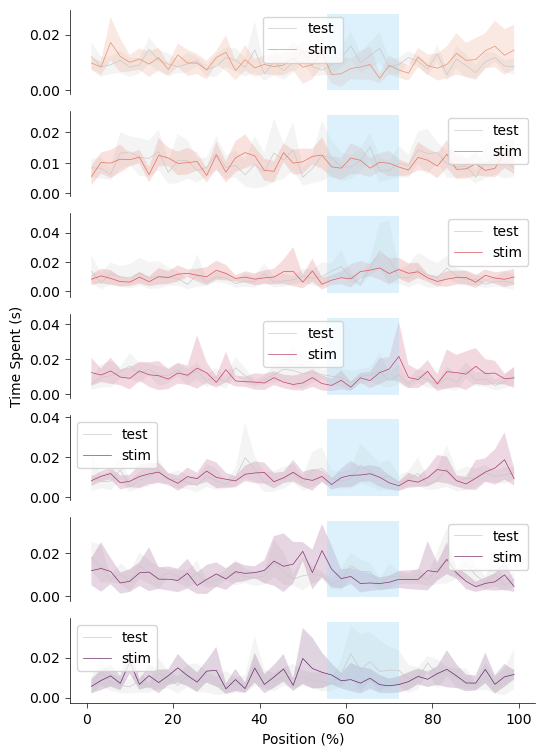

In [17]:
fig, axes = plt.subplots(nrows=7, ncols=1, figsize=(6, 9))
colors = sns.color_palette("flare", 7)
led_powers = [0, 0.2, 0.5, 0.8, 1.5, 3.0, 5.0]
for i, ax in enumerate(axes):
    if i == 6:
        ax = Clear_Axes(ax, close_spines = ['top', 'right'], ifxticks=True, ifyticks=True)
    else:
        ax = Clear_Axes(ax, close_spines = ['top', 'right', 'bottom'], ifyticks=True)
    idx = np.where((data["LED Power"] >= led_powers[i] - 1e-3) & (data["LED Power"] < led_powers[i] + 1e-3) & (data["Group"] == "Negative"))[0]
    print(idx.shape[0])
    sns.lineplot(
        x=data["Pos"][idx],
        y=data["Time"][idx],
        hue=data["Label"][idx],
        ax=ax,
        palette=["#c9caca", colors[i]],
        hue_order=["test", "stim"],
        linewidth=0.5,
        err_kws={"edgecolor": None}
    )
    ax.fill_betweenx(ax.get_ylim(), 500/9, 1300/18, color="#a9dcf5", alpha=0.4, edgecolor=None)
    ax.set_xlabel("Position (%)")
    if i==3:
        ax.set_ylabel("Time Spent (s)")
    else:
        ax.set_ylabel("")
plt.savefig(os.path.join(loc, "time_spent_by_pos [Negative Fish].png"), dpi=300)
plt.savefig(os.path.join(loc, "time_spent_by_pos [Negative Fish].svg"), dpi=300)
plt.show()

# Statistic Test

140
LED Power: 0
    neg: TtestResult(statistic=-4.546760546043835, pvalue=0.0061306434860091295, df=5)
LED Power: 0.2
    neg: TtestResult(statistic=-0.38423555155681666, pvalue=0.7166020289196149, df=5)
    pos: TtestResult(statistic=-1.9090662206092615, pvalue=0.12888453586869236, df=4)
LED Power: 0.5
    neg: TtestResult(statistic=-0.5385980012024861, pvalue=0.6132683480044248, df=5)
    pos: TtestResult(statistic=-1.3254059601960377, pvalue=0.2769327611919804, df=3)
LED Power: 0.8
    neg: TtestResult(statistic=0.129157272629035, pvalue=0.9022679185926641, df=5)
    pos: TtestResult(statistic=-2.0651449802548534, pvalue=0.13084908959442215, df=3)
LED Power: 1.5
    pos: TtestResult(statistic=-1.117347312389135, pvalue=0.34526636752342754, df=3)
LED Power: 3.0
    neg: TtestResult(statistic=-1.0299240751828331, pvalue=0.36124524022386423, df=4)
    pos: TtestResult(statistic=-0.889615057656222, pvalue=0.4392073835043119, df=3)
LED Power: 5.0
    neg: TtestResult(statistic=-1.557340

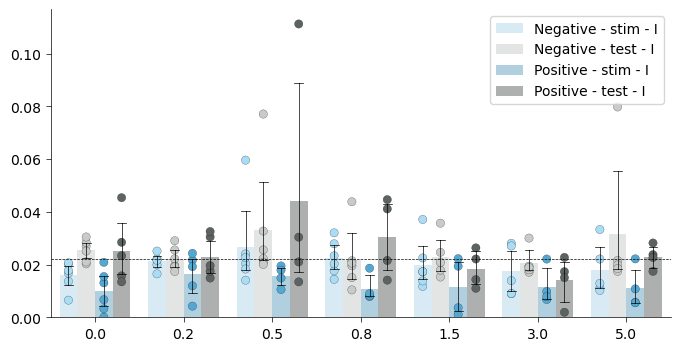

In [15]:
if os.path.exists(os.path.join(figdata, f" {code_id} [avg].pkl")) == False:
    idx = (data['Pos'] >= 500/9-1e-3) & (data['Pos'] < 1300/18+1e-3)
    idx_out = (data['Pos'] < 500/9+1e-3) | (data['Pos'] >= 1300/18-1e-3)
    subdata = SubDict(data, idx)
    subdata_out = SubDict(data, idx_out)
    avg_data = {
        "LED Power": [],
        "Group": [],
        "Label": [],
        "I/O": [],
        "Hue": [],
        "Avg Time": []
    }
    for fish_id in np.unique(subdata['Fish ID']):
        for gp in ["Negative", "Positive"]:
            for led_power in [0, 0.2, 0.5, 0.8, 1.5, 3.0, 5.0]:
                for label in ["stim", "test"]:
                    idx_ = np.where(
                        (subdata['Group'] == gp) & 
                        (subdata['Label'] == label) & 
                        (subdata['Fish ID'] == fish_id) & 
                        (subdata['LED Power'] <= led_power + 1e-3) &
                        (subdata['LED Power'] >= led_power - 1e-3)
                    )[0]
                    if idx_.shape[0] == 0:
                        continue
                    avg_time = np.mean(subdata['Time'][idx_]) * 100/45
                    avg_data["LED Power"].append(subdata['LED Power'][idx_][0])
                    avg_data["Group"].append(gp)
                    avg_data["Label"].append(label)
                    avg_data["Hue"].append(f"{gp} - {label} - I")
                    avg_data["I/O"].append("I")
                    avg_data["Avg Time"].append(avg_time)
    
    for key in avg_data:
        avg_data[key] = np.array(avg_data[key])
        
    with open(os.path.join(figdata, f"{code_id} [avg].pkl"), "wb") as f:
        pickle.dump(avg_data, f)
        
    AVGDATA = pd.DataFrame(avg_data)
    AVGDATA.to_excel(os.path.join(figdata, f"{code_id} [avg].xlsx"), index=False)
    print(len(AVGDATA))
else:
    with open(os.path.join(figdata, f"{code_id} [avg].pkl"), "rb") as f:
        avg_data = pickle.load(f)

fig, ax = plt.subplots(figsize=(8, 4))
ax = Clear_Axes(ax, close_spines = ['top', 'right'], ifxticks=True, ifyticks=True)
sns.barplot(
    x=avg_data["LED Power"],
    y=avg_data["Avg Time"],
    hue=avg_data["Hue"],
    ax=ax,
    palette=["#a9dcf5", "#c9caca", "#52a8d3", "#5D6363"],
    capsize=0.4,
    linewidth=0.5,
    err_kws={'color': 'k', 'linewidth': 0.5},
    alpha=0.5
)
sns.stripplot(
    x=avg_data["LED Power"],
    y=avg_data["Avg Time"],
    hue=avg_data["Hue"],
    ax=ax,
    palette=["#a9dcf5", "#c9caca", "#52a8d3", "#5D6363"],
    dodge=True,
    jitter=0,
    size=6,
    edgecolor="k",
    linewidth=0.15,
    legend=False,
    zorder=1
)
ax.axhline(1/45, color="k", linestyle="--", linewidth=0.5)
for led_power in [0, 0.2, 0.5, 0.8, 1.5, 3.0, 5.0]:
    idx_neg_stim = np.where((avg_data["LED Power"] == led_power) & (avg_data["Group"] == "Negative") & (avg_data["Label"] == "stim"))[0]
    idx_neg_test = np.where((avg_data["LED Power"] == led_power) & (avg_data["Group"] == "Negative") & (avg_data["Label"] == "test"))[0]
    idx_pos_stim = np.where((avg_data["LED Power"] == led_power) & (avg_data["Group"] == "Positive") & (avg_data["Label"] == "stim"))[0]
    idx_pos_test = np.where((avg_data["LED Power"] == led_power) & (avg_data["Group"] == "Positive") & (avg_data["Label"] == "test"))[0]
    
    print(f"LED Power: {led_power}")
    if idx_neg_stim.shape[0] == idx_neg_test.shape[0]:
        print(f"    neg: {ttest_rel(avg_data['Avg Time'][idx_neg_stim], avg_data['Avg Time'][idx_neg_test])}")
    if idx_pos_stim.shape[0] == idx_pos_test.shape[0]:  
        print(f"    pos: {ttest_rel(avg_data['Avg Time'][idx_pos_stim], avg_data['Avg Time'][idx_pos_test])}")
plt.savefig(os.path.join(loc, "LED Gradient Statistics.png"), dpi=300)
plt.savefig(os.path.join(loc, "LED Gradient Statistics.svg"), dpi=300)
plt.show()

In [20]:
res = import16chFlt(r"D:\EnData\dat\10203\S2\res.16chFlt")
print(res['Paradigm'][0])

20251112


# Reward Translocation

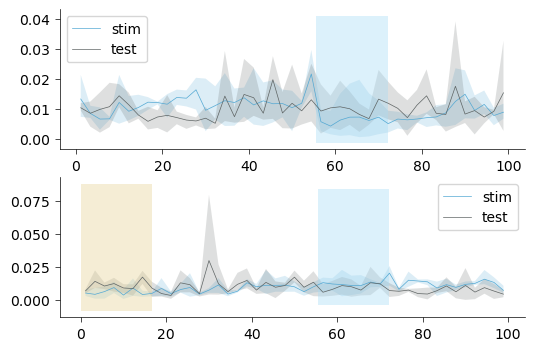

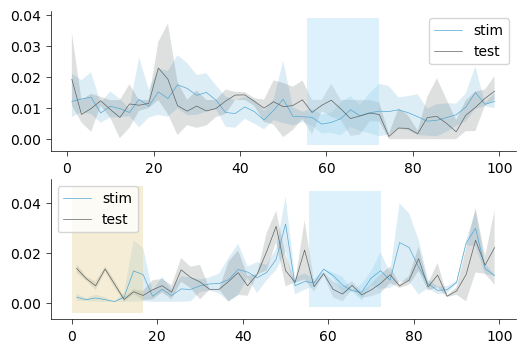

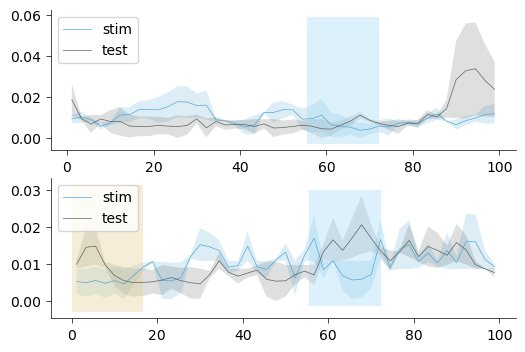

In [3]:
if exists(os.path.join(figdata, f"{code_id} [Translocation].pkl")) == False:
    TransLocData = {
        "Fish ID": [],
        "Group": [],
        "Pos": [],
        "Time": [],
        "Label": [],
        "Reward Loc": []
    }
    
    data_dir = [
        r"D:\EnData\dat\Negative - datCoChr-\10190\S3-Translocation\res.16chFlt",
        r"D:\EnData\dat\Negative - datCoChr-\10195\S3 Translocation\res.16chFlt",
        r"D:\EnData\dat\Negative - datCoChr-\10197\S3 Translocation\res.16chFlt",
        r"D:\EnData\dat\10202\S3 Translocation\res.16chFlt",
        r"D:\EnData\dat\10203\S3 Translocation\res.16chFlt",
        r"D:\EnData\dat\10204\S2 Translocation\-2res.16chFlt",
        r"D:\EnData\dat\10205\S2\res.16chFlt",
        r"D:\EnData\dat\10202\S4 Translocation, long-lasting single pulse\res.16chFlt",
        r"D:\EnData\dat\10205\S3 Translation, long single pulse\res.16chFlt"
    ]
    group = [
        "Negative", "Negative", "Negative", "Positive", "Positive", "Positive", "Positive", "Long-Lasting", "Long-Lasting"
    ]
    fish_id = [
        10190, 10195, 10197, 10202, 10203, 10204, 10205, 10202, 10205
    ]

    for n, dp, gp, fid in tqdm(zip(range(len(data_dir)), data_dir, group, fish_id)):
        
        res = import16chFlt(dp)
        idx = np.where(
            (res['behav_time'] > 5) &
            (res['behav_pos_y'] >= 0) &
            (res['behav_pos_y'] < 55) &
            (res['n_trials'] < 40)
        )[0]
        for k in res.keys():
            res[k] = res[k][idx]

        res['behav_pos_y'] = res['behav_pos_y']*2

        indices = [
            (np.where((res['n_trials'] >= i*10) & (res['n_trials'] < (i+1)*10))[0], ["Location 1", "Location 2"][i//2], ["stim", "test"][i%2]) for i in range(4)
        ]        
        
        x = np.linspace(0, 100, 46)
        x = (x[:-1] + x[1:])/2
        for it in indices:
            idx, label, stim_test = it
            if idx.shape[0] < 6000:
                continue
            tt = np.histogram(res['behav_pos_y'][idx], bins = 45, range=(0,100), density=True)[0]
            
            TransLocData["Fish ID"].append(np.repeat(fid, len(tt)))
            TransLocData["Group"].append(np.repeat(gp, len(tt)))    
            TransLocData["Pos"].append(x)
            TransLocData["Time"].append(tt)
            TransLocData["Label"].append(np.repeat(stim_test, len(tt))) 
            TransLocData["Reward Loc"].append(np.repeat(label, len(tt)))
            
    for key in TransLocData:
        TransLocData[key] = np.concatenate(TransLocData[key])
        
    with open(os.path.join(figdata, f"{code_id} [Translocation].pkl"), "wb") as f:
        pickle.dump(TransLocData, f)
        
    RewardLocD = pd.DataFrame(TransLocData)
    RewardLocD.to_excel(os.path.join(figdata, f"{code_id} [Translocation].xlsx"), index=False)
    print(len(RewardLocD))
else:
    with open(os.path.join(figdata, f"{code_id} [Translocation].pkl"), "rb") as f:
        TransLocData = pickle.load(f)

for gp in ["Negative", "Positive", "Long-Lasting"]:
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 4))
    ax1 = Clear_Axes(axes[0], close_spines = ['top', 'right'], ifxticks=True, ifyticks=True)
    ax2 = Clear_Axes(axes[1], close_spines = ['top', 'right'], ifxticks=True, ifyticks=True)
    subdata_loc1 = SubDict(TransLocData, (TransLocData["Reward Loc"] == "Location 1")&(TransLocData["Group"] == gp))
    subdata_loc2 = SubDict(TransLocData, (TransLocData["Reward Loc"] == "Location 2")&(TransLocData["Group"] == gp))
    sns.lineplot(
        x=subdata_loc1["Pos"],
        y=subdata_loc1["Time"],
        hue=subdata_loc1["Label"],
        ax=ax1,
        palette=["#52a8d3", "#5D6363"],
        hue_order=["stim", "test"],
        linewidth=0.5,
        err_kws={"edgecolor": None}
    )
    ax1.fill_betweenx(ax1.get_ylim(), 500/9, 1300/18, color="#a9dcf5", alpha=0.4, edgecolor=None)
    sns.lineplot(
        x=subdata_loc2["Pos"],
        y=subdata_loc2["Time"],
        hue=subdata_loc2["Label"],
        ax=ax2,
        palette=["#52a8d3", "#5D6363"],
        hue_order=["stim", "test"],
        linewidth=0.5,
        err_kws={"edgecolor": None}
    )
    ax2.fill_betweenx(ax2.get_ylim(), 500/9, 1300/18, color="#a9dcf5", alpha=0.4, edgecolor=None)
    ax2.fill_betweenx(ax2.get_ylim(), 0, 300/18, color="#e8d498", alpha=0.4, edgecolor=None)
    plt.savefig(os.path.join(loc, f"Reward Translocation [{gp}].png"), dpi=300)
    plt.savefig(os.path.join(loc, f"Reward Translocation [{gp}].svg"), dpi=300)
    plt.show()

# Others

In [3]:
path = r"D:\EnData\dat\10166\S2\res.16chFlt"
path_pre = r"D:\EnData\dat\10166\S1\res.16chFlt"
res = import16chFlt(path)
res_pre = import16chFlt(path_pre)
fish_id = 10166

# Check LED-invoked responses

In [ ]:
def process_led_invoked_responses(data_dir: str):
    res = import16chFlt(data_dir)
    template_led_power = np.array([0, 0.2, 0.5, 0.8, 1.5, 3, 5])
    
    keep_indices = np.where(
        (res['behav_time'] > 5) &
        (res['behav_pos_y'] >= 0) &
        (res['behav_pos_y'] < 55) &
        (res['n_trials'] < 150)
    )[0]
    for k in res.keys():
        res[k] = res[k][keep_indices]
    
    res['behav_pos_y'] *= 2
    
    led_power = res['led_power']
    opt_state = res['opto_states']

    
    pos = res['behav_pos_y'].copy()
    dpos = np.append(np.diff(res['behav_pos_y']), 0)
    dpos[dpos<0] += 100
    dt = np.append(np.diff(res['behav_time']), 1e-3)
    smoothed_speed = np.convolve(dpos, np.ones(200), mode='same') / np.convolve(dt, np.ones(200), mode='same')
    smoothed_ch1 = np.convolve(res['fltCh0'], np.ones(200), mode='same') / np.convolve(np.ones_like(res['fltCh0']), np.ones(200), mode='same')
    smoothed_ch2 = np.convolve(res['fltCh1'], np.ones(200), mode='same') / np.convolve(np.ones_like(res['fltCh1']), np.ones(200), mode='same')
    
    led_power = led_power[::100]
    smoothed_speed = smoothed_speed[::100]
    smoothed_ch1 = smoothed_ch1[::100]
    smoothed_ch2 = smoothed_ch2[::100]
    t = res['behav_time'][::100]
    
    opt_state = opt_state[::100]
    dstate = np.append(np.diff(opt_state), 0)
    led_on_indices = np.where(dstate == 1)[0]+1   
     
    data = {
        "LED Power": [],
        "Time To LED Onset": [],
        "Ch1": [],
        "Ch2": [],
        "Speed": [],
        "n_Trials": []
    }
    for n, idx in tqdm(enumerate(led_on_indices)):
        if n >= 150:
            break
        
        frame_range = [max(0, idx - 600), min(len(res['behav_time']), idx + 600)]
        
        led_power_idx = np.argmin(np.abs(template_led_power - led_power[int((frame_range[0]+frame_range[1])/2)]))
        
        _len = smoothed_speed[frame_range[0]:frame_range[1]].shape[0]
        data["LED Power"].append(np.repeat(template_led_power[led_power_idx], _len))
        data["Time To LED Onset"].append(t[frame_range[0]:frame_range[1]] - t[idx])
        data["Ch1"].append(smoothed_ch1[frame_range[0]:frame_range[1]])
        data["Ch2"].append(smoothed_ch2[frame_range[0]:frame_range[1]])
        data["Speed"].append(smoothed_speed[frame_range[0]:frame_range[1]])
        data["n_Trials"].append(np.repeat(n, _len))
    
    for k in data.keys():
        data[k] = np.concatenate(data[k])
        
    
    return data

path = r"D:\EnData\dat\Negative - GCaMP8m\10176\S2\res.16chFlt"
data = process_led_invoked_responses(path)

138it [00:00, 46028.94it/s]


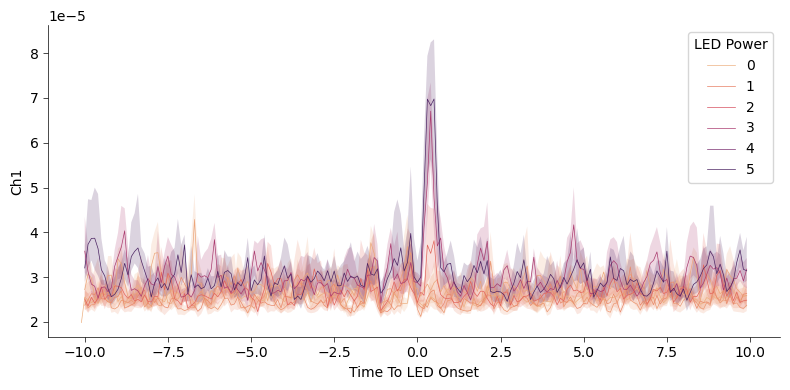

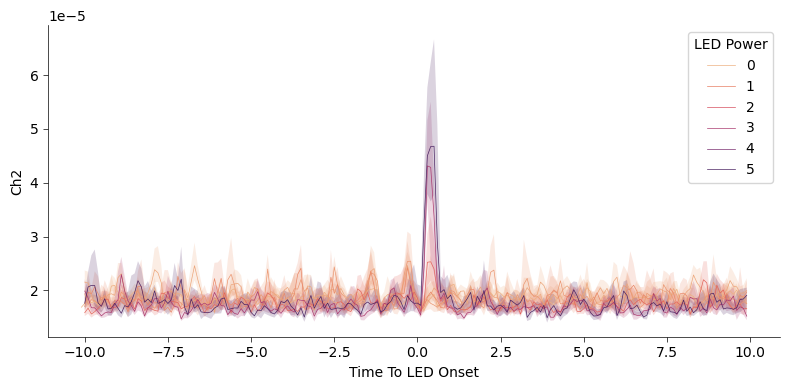

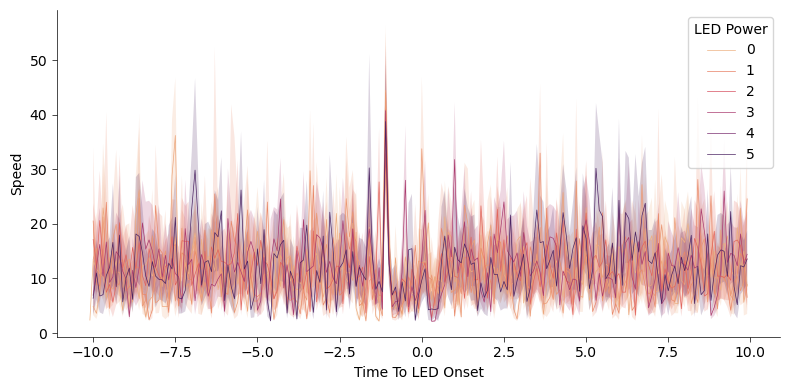

In [43]:
data['Time To LED Onset'] = (data['Time To LED Onset'] // 0.1)*0.1

fig = plt.figure(figsize=(8, 4))
ax = Clear_Axes(plt.axes(), close_spines = ['top', 'right'], ifxticks=True, ifyticks=True)
sns.lineplot(
    x="Time To LED Onset", 
    y="Ch1", 
    data=data, 
    ax=ax,
    hue='LED Power',
    linewidth=0.5,
    err_kws={'edgecolor': None},
    palette = "flare",
    estimator=np.median
)
plt.tight_layout()
plt.show()
fig = plt.figure(figsize=(8, 4))
ax = Clear_Axes(plt.axes(), close_spines = ['top', 'right'], ifxticks=True, ifyticks=True)
sns.lineplot(
    x="Time To LED Onset", 
    y="Ch2", 
    data=data, 
    ax=ax,
    hue='LED Power',
    linewidth=0.5,
    err_kws={'edgecolor': None},
    palette = "flare",
    estimator=np.median
)
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(8, 4))
ax = Clear_Axes(plt.axes(), close_spines = ['top', 'right'], ifxticks=True, ifyticks=True)
sns.lineplot(
    x="Time To LED Onset", 
    y="Speed", 
    data=data, 
    ax=ax,
    hue='LED Power',
    linewidth=0.5,
    err_kws={'edgecolor': None},
    palette = "flare"
)
plt.tight_layout()
plt.show()

# All Fish

138it [00:00, 13798.04it/s]
150it [00:00, 24985.93it/s]
150it [00:00, 30003.61it/s]
150it [00:00, 24968.08it/s]
4it [00:27,  6.91s/it]


5572


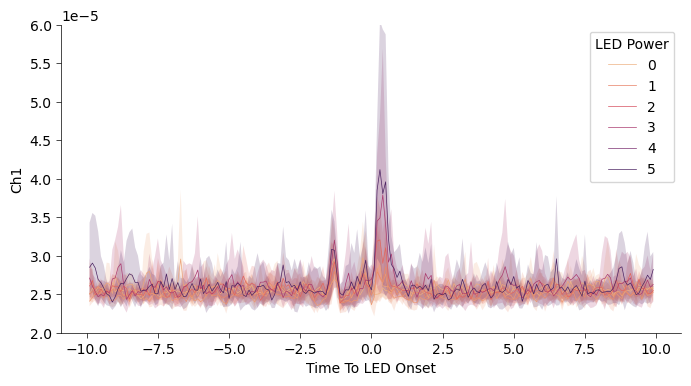

In [45]:
if os.path.exists(os.path.join(figdata, f" {code_id} [opt response].pkl")) == False:
    OptRes = {
        "FishID": [],
        "LED Power": [],
        "Time To LED Onset": [],
        "Ch1": [],
        "Ch2": [],
        "Speed": []
    }
    for fish, path in tqdm(zip(
        [10176, 10177, 10178, 10179], 
        [
            r"D:\EnData\dat\Negative - GCaMP8m\10176\S2\res.16chFlt",
            r"D:\EnData\dat\Negative - GCaMP8m\10177\S2\res.16chFlt",
            r"D:\EnData\dat\Negative - GCaMP8m\10178\S2\res.16chFlt",
            r"D:\EnData\dat\Negative - GCaMP8m\10179\S2\res.16chFlt"
        ]
    )):
        data = process_led_invoked_responses(path)
        data['Time To LED Onset'] = (data['Time To LED Onset'] // 0.1)
        for led_power in np.unique(data['LED Power']):
            t = np.linspace(-99, 99, 199)
            for tb in t:
                idx = np.where((data['LED Power'] < led_power+1e-3) & (data['LED Power'] >= led_power-1e-3) & (data['Time To LED Onset'] == tb))[0]
                if len(idx) == 0:
                    continue
                
                OptRes["FishID"].append(fish)
                OptRes["LED Power"].append(data['LED Power'][idx[0]])
                OptRes["Time To LED Onset"].append(tb)
                OptRes["Ch1"].append(np.median(data['Ch1'][idx]))
                OptRes["Ch2"].append(np.median(data['Ch2'][idx]))
                OptRes["Speed"].append(np.median(data['Speed'][idx]))
        
    for k in OptRes.keys():
        OptRes[k] = np.array(OptRes[k])
    
    with open(os.path.join(figdata, f"{code_id} [opt response].pkl"), 'wb') as f:
        pickle.dump(OptRes, f)
else:
    with open(os.path.join(figdata, f"{code_id} [opt response].pkl"), 'rb') as f:
        OptRes = pickle.load(f)

OptRes['Time To LED Onset'] = OptRes['Time To LED Onset'] * 0.1
print(len(OptRes['FishID']))
fig = plt.figure(figsize=(8, 4))
ax = Clear_Axes(plt.axes(), close_spines = ['top', 'right'], ifxticks=True, ifyticks=True)
sns.lineplot(
    x="Time To LED Onset", 
    y="Ch1", 
    data=OptRes, 
    ax=ax,
    hue='LED Power',
    linewidth=0.5,
    err_kws={'edgecolor': None},
    palette = "flare"
)
ax.set_ylim(2e-5, 6e-5)
plt.show()

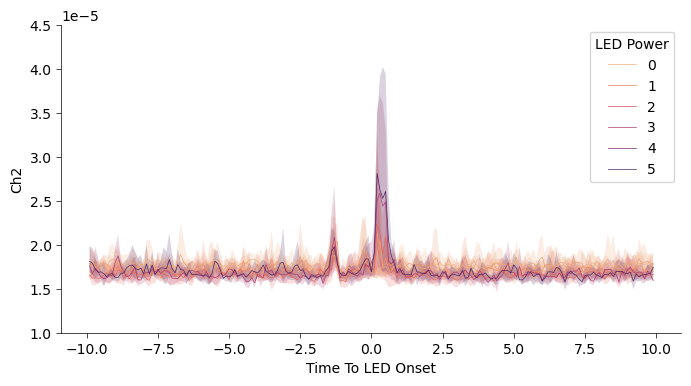

In [30]:
fig = plt.figure(figsize=(8, 4))
ax = Clear_Axes(plt.axes(), close_spines = ['top', 'right'], ifxticks=True, ifyticks=True)
sns.lineplot(
    x="Time To LED Onset", 
    y="Ch2", 
    data=OptRes, 
    ax=ax,
    hue='LED Power',
    linewidth=0.5,
    err_kws={'edgecolor': None},
    palette = "flare"
)
ax.set_ylim(1e-5, 4.5e-5)
plt.show()

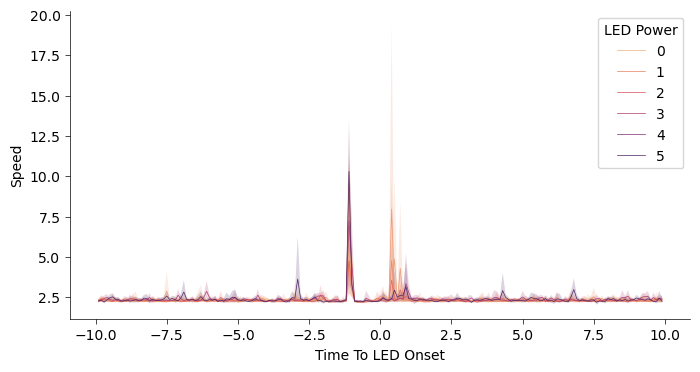

In [32]:
fig = plt.figure(figsize=(8, 4))
ax = Clear_Axes(plt.axes(), close_spines = ['top', 'right'], ifxticks=True, ifyticks=True)
sns.lineplot(
    x="Time To LED Onset", 
    y="Speed", 
    data=OptRes, 
    ax=ax,
    hue='LED Power',
    linewidth=0.5,
    err_kws={'edgecolor': None},
    palette = "flare"
)
plt.show()

# Time Spend for each trial

[0.  0.2 0.5 0.8 1.5 3.  5. ]


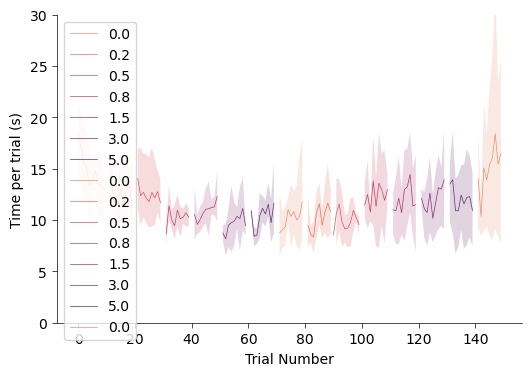

In [62]:
def process_time_spend(data_path: str):
    res = import16chFlt(data_path)
    print(np.unique(res['led_power']))
    template_led_power = np.array([0, 0.2, 0.5, 0.8, 1.5, 3, 5])
    
    keep_indices = np.where(
        (res['behav_time'] > 5) &
        (res['behav_pos_y'] >= 0) &
        (res['behav_pos_y'] < 55) &
        (res['n_trials'] < 150)
    )[0]
    for k in res.keys():
        res[k] = res[k][keep_indices]
    
    res['behav_pos_y'] *= 2
    t = res['behav_time']
    
    data = {
        "LED Power": [],
        "Time Spent": [],
        "n_Trials": []
    }
    for i in range(150):
        idx = np.where(res['n_trials'] == i)[0]
        if len(idx) == 0:
            continue
        
        time_spent = t[idx[-1]] - t[idx[0]]
        led_power_idx = np.argmin(np.abs(res['led_power'][idx[int(len(idx)/2)]] - template_led_power))
        data["Time Spent"].append(time_spent)
        data["LED Power"].append(template_led_power[led_power_idx])
        data["n_Trials"].append(i)
    return data

if os.path.exists(os.path.join(figdata, f"{code_id} [time spent].pkl")) == False:
    TimeSpent = {
        "FishID": [],
        "LED Power": [],
        "n_Trials": [],
        "Time Spent": []
    }
    for fish, path in tqdm(zip(
        [10176, 10177, 10178, 10179], 
        [
            r"D:\EnData\dat\Negative - GCaMP8m\10176\S2\res.16chFlt",
            r"D:\EnData\dat\Negative - GCaMP8m\10177\S2\res.16chFlt",
            r"D:\EnData\dat\Negative - GCaMP8m\10178\S2\res.16chFlt",
            r"D:\EnData\dat\Negative - GCaMP8m\10179\S2\res.16chFlt"
        ]
    )):
        data = process_time_spend(path)
        TimeSpent["FishID"].append(np.repeat(fish, len(data['LED Power'])))
        TimeSpent["LED Power"].append(data['LED Power'])
        TimeSpent["n_Trials"].append(data['n_Trials'])
        TimeSpent["Time Spent"].append(data['Time Spent'])
    
    for k in TimeSpent.keys():
        TimeSpent[k] = np.concatenate(TimeSpent[k])
    
    with open(os.path.join(figdata, f"{code_id} [time spent].pkl"), 'wb') as f:
        pickle.dump(TimeSpent, f)
        
    TimeSpentD = pd.DataFrame(TimeSpent)
    TimeSpentD.to_excel(os.path.join(figdata, f"{code_id} [time spent].xlsx"), index=False)
    print(len(TimeSpent['FishID']))
else:
    with open(os.path.join(figdata, f"{code_id} [time spent].pkl"), 'rb') as f:
        TimeSpent = pickle.load(f)
        
fig = plt.figure(figsize=(6, 4))
ax = Clear_Axes(plt.axes(), close_spines = ['top', 'right'], ifxticks=True, ifyticks=True)
led_power_levels = np.array([0, 0.2, 0.5, 0.8, 1.5, 3, 5])
print(np.unique(TimeSpent['LED Power']))
colors = sns.color_palette("flare", 7)
for nt in range(15):
    idx = np.where(
        (TimeSpent['n_Trials'] < (nt+1)*10) & 
        (TimeSpent['n_Trials'] >= nt*10) & 
        (TimeSpent['LED Power'] > led_power_levels[nt % 7] - 1e-3) &
        (TimeSpent['LED Power'] <= led_power_levels[nt % 7] + 1e-3)
    )[0]
    if len(idx) == 0:
        continue    
    sns.lineplot(
        x=TimeSpent['n_Trials'][idx], 
        y=TimeSpent['Time Spent'][idx], 
        hue=TimeSpent['LED Power'][idx],
        ax=ax,
        palette = [colors[nt%7]],
        linewidth=0.5,
        err_kws={'edgecolor': None}
    )
ax.set_ylim(0, 30)
ax.set_ylabel("Time per trial (s)")
ax.set_xlabel("Trial Number")
plt.show()


# Visuaize swim power trial-by-trial.

100%|██████████| 15/15 [00:13<00:00,  1.14it/s]


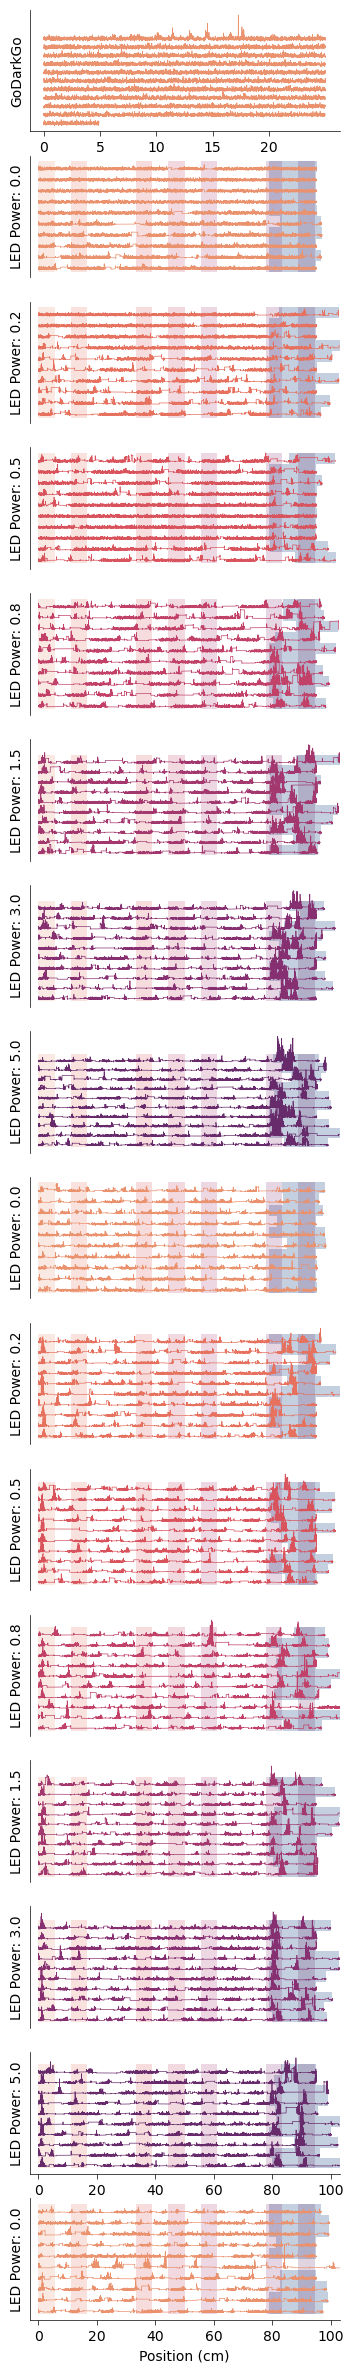

In [18]:
def visualize(res, res_pre, param: str = 'speed'):
    idx = np.where(
        (res['behav_time'] >= 5) &
        (res['behav_pos_y'] <= 55) &
        (res['behav_pos_y'] >= 0)
    )
    for k in res.keys():
        res[k] = res[k][idx]
        
    led_power_color = sns.color_palette("flare", 7)
    led_power_colors = led_power_color + led_power_color + [led_power_color[0]]
    
    pos = res['behav_pos_y'] * 2
    indices = [
        np.where(res['n_trials']<10)[0],
        np.where((res['n_trials']>=10) & (res['n_trials']<20))[0],
        np.where((res['n_trials']>=20) & (res['n_trials']<30))[0],
        np.where((res['n_trials']>=30) & (res['n_trials']<40))[0],
        np.where((res['n_trials']>=40) & (res['n_trials']<50))[0],
        np.where((res['n_trials']>=50) & (res['n_trials']<60))[0],
        np.where((res['n_trials']>=60) & (res['n_trials']<70))[0],
        np.where((res['n_trials']>=70) & (res['n_trials']<80))[0],
        np.where((res['n_trials']>=80) & (res['n_trials']<90))[0],
        np.where((res['n_trials']>=90) & (res['n_trials']<100))[0],
        np.where((res['n_trials']>=100) & (res['n_trials']<110))[0],
        np.where((res['n_trials']>=110) & (res['n_trials']<120))[0],
        np.where((res['n_trials']>=120) & (res['n_trials']<130))[0],
        np.where((res['n_trials']>=130) & (res['n_trials']<140))[0],
        np.where((res['n_trials']>=140) & (res['n_trials']<150))[0],
    ]
    
    avg_swim_power = np.mean(np.vstack([res['fltCh0'], res['fltCh1']]), axis=0)
    
    fig, axes = plt.subplots(ncols=1, nrows=16, figsize=(4, 30))
    ax_pre = Clear_Axes(axes[0], close_spines=['top', 'right'], ifxticks=True)
    ax_pre.set_xlabel("Time (s)")
    ax_pre.set_xticks(np.linspace(0, 20, 5))
    ax_pre.set_ylabel("GoDarkGo")
    trial_uniq = np.unique(res_pre['n_trials'])
    base = 0
    for trial in trial_uniq:
        trial_idx = np.where(res_pre['n_trials'] == trial)[0]
        ax_pre.plot(res_pre['behav_time'][trial_idx]-res_pre['behav_time'][trial_idx][0], res_pre['fltCh0'][trial_idx]+res_pre['fltCh1'][trial_idx] - base, lw=0.5, color=led_power_colors[0])
        base += 1e-4
    
    for i in tqdm(range(1, 16)):
        if i < 14:
            ax = Clear_Axes(axes[i], close_spines=['top', 'right', 'bottom'])
        else:
            ax = Clear_Axes(axes[i], close_spines=['top', 'right'], ifxticks=True)
            ax.set_xlabel("Position (cm)")
            ax.set_xticks(np.linspace(0, 100, 6))
            
        idx = indices[i-1]
        
        trials = np.unique(res['n_trials'][idx])
        speed_base = 0
        swim_power_base = 0
        for trial in trials:
            trial_idx = np.where(res['n_trials'][idx] == trial)[0]
            opt_onset_idx = np.where(res['opto_states'][idx][trial_idx] == 1)[0]
            pos_readjust = pos[idx][trial_idx].copy()
            for j in range(1, len(pos_readjust)):
                if pos_readjust[j] < pos_readjust[j-1]:
                    pos_readjust[j] += 100
                    
            dx = np.diff(pos_readjust)
            dt = np.diff(res['behav_time'][idx][trial_idx])
            dx[dx<0] = 0
            swim_speed = np.convolve(dx, np.ones(200), mode='same') / np.convolve(dt, np.ones(200), mode='same')
            swim_speed = np.concatenate([[0], swim_speed])
            t = res['behav_time'][idx][trial_idx] - res['behav_time'][idx][trial_idx][0]
            speed_binned = np.zeros(200) * np.nan
            for j in range(200):    
                bin_idx = np.where((pos_readjust >= j*0.5) & (pos_readjust < (j+1)*0.5))[0]
                if len(bin_idx) > 0:
                    speed_binned[j] = np.nanmean(swim_speed[bin_idx])
            
            # Interpolate the speed_binned to fill the NaN values
            for j in range(200):
                if np.isnan(speed_binned[j]):
                    if j == 0:
                        speed_binned[j] = 0
                    else:
                        speed_binned[j] = speed_binned[j-1]
            
            
            speed_base_unit = 300
            speed_base += speed_base_unit   
            swim_power_base_unit = 1e-4
            swim_power_base += swim_power_base_unit    
            ax.fill_betweenx(y=[-swim_power_base, -swim_power_base+swim_power_base_unit], alpha=0.3, color=ChannelColors[1], edgecolor=None, x1=pos_readjust[opt_onset_idx[0]], x2=pos_readjust[opt_onset_idx[-1]])
            ax.plot(pos_readjust, avg_swim_power[idx][trial_idx] - swim_power_base, lw=0.5, color = led_power_colors[i-1])
            #ax.fill_betweenx(y=[-speed_base, -speed_base+speed_base_unit], alpha=0.3, color=ChannelColors[1], edgecolor=None, x1=pos_readjust[opt_onset_idx[0]], x2=pos_readjust[opt_onset_idx[-1]])
            #ax.plot(np.linspace(0.25, 99.75, 200), speed_binned-speed_base, lw=0.5, color = led_power_colors[i-1])

        for j, (start, end) in enumerate(landmark_pos):
            ax.fill_betweenx(y=[-swim_power_base_unit*10, 0], alpha=0.2, color=led_power_colors[j], edgecolor=None, x1=start*100, x2=end*100)
            #ax.fill_betweenx(y=[-speed_base_unit*10, 0], alpha=0.2, color=ChannelColors[0], edgecolor=None, x1=start*100, x2=end*100)
        ax.set_ylabel(f"LED Power: {res['led_power'][idx][int(idx.shape[0]/2)]:.1f}")
        ax.set_xlim(-3, 103)
    plt.savefig(os.path.join(loc, f"Swim Power Distribution [{fish_id}].png"), dpi=600)
    plt.savefig(os.path.join(loc, f"Swim Power Distribution [{fish_id}].svg"), dpi=600)
    plt.show()
    
visualize(res, res_pre, param='speed')